# The futile, yet often successful, quest for representational comparisons

The aim of this tutorial is to ground the major intuitions / arguments provided for why the comparison of neural representations is possible and meaningful into a theoretically grounded framework. We often have a mental picture of why something should or should not work - we hope that we can expand and refine your mental picture of neural activation patterns and why and when comparing them may or may not be meaningful.

The general idea of representational comparisons is that ...

**INSERT CUTE PICTURE HERE**

Throughout this tutorial, we use the term _neural network_ broadly to denote both biological and artificial systems and assume that despite their very different implementational constraints (e.g. architecture, learning rules, etc.) they both follow the foundational principle of connectionism: function emerges from parallel computations among simple, interconnected units that generate and rely on neural representations. Accordingly, we assume that we can study and think about biological and artificial neural computations by analysis of their neural activation patterns. 

In this tutorial we are going to investigate and challenge three major intuitions underlying representational similarity analysis:
1. **Functional equivalence implies representational alignment**: If two systems implement the same (or similar) input-output function, comparisons of neural activity are well-posed
2. **Task demands drive representational convergence ("contravariance")**: Increasing task difficulty or ecological validty reduces the space of admissible representations, therby promoting convergence across systems
3. **Existance of a privileged or normative representation**: For a given task, there exists a preferable ground truth representation, and models implementing it are better than others

From these intuitions, the following two conclusions are frequently derived:
1. **Data statistics determine representation**: The structure of the environment or task induce the existence of a unique, optimal, and thus comparable representation
2. **Metric adequacy resolves representational questions**: The validity of a comparison depends on the choice of metric, the right metric can accurately determine similarity

Throught this tutorial, we are going to challenge these intuitions and conclusions and show that they can quickly turn into fallacies, leading to ill-posed scientific questions.

## Two-layer linear networks

To ground our claims and analysis, we begin the tutorial with one of the most simple neural networks: two-layer linear networks. Despite their almost laughable level of complexity, they are extreamly helpful for our mission for five reasons:
1. They make use of hidden-layer representations
2. They are easy to study numerically and anlytically
3. The best they can do is performing linear regression (which we have a very good unsertanding of)
4. They have a well-defined solution manifold, which makes questions of "optimality" tracktable for any given task
5. This notion of optimality allows us to study representationa learning independent of the choice of learning algorithm, hyperparameters etc.

If this sounds overwhelming or confusing - don't you worry - we will go slowly and step by step and these points will become clear to you in no time!

### The network function
Two-layer linear networks have two weight matrices, a single input and a single output weight matrix. Given a set of $P$ inputs that we gather in the matrix $\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_P]$ and the corresponding collection of target outputs $\mathbf{Y} = [\mathbf{y}_1, \mathbf{y}_2, ..., \mathbf{y}_P]$, the input weight matrix $\mathbf{W}_1$ maps inputs to corresponding hidden representations,
$$\mathbf{H} = \mathbf{W}_1\mathbf{X},$$
which are then projected to network outputs via the readout weight matrix
$$\mathbf{\hat Y} = \mathbf{W}_2\mathbf{H}.$$
We can thus write the whole network function as
$$\mathbf{\hat Y} = \mathbf{W}_2\mathbf{W}_1\mathbf{X}.$$

**INSERT CUTE PICTURE HERE**

Let's begin by implementing the network funtion:

In [38]:
import jax.numpy as np
import jax
import matplotlib.pyplot as plt

In [39]:
def linear_network(w1, w2, x):
    return w2 @ w1 & x # TODO: Implement the network function

Well that was quick an easy! However, a network function is only useful and interesting when combined with a task!

### The semantic hierarchy task
Let's begin by defining and implementing an example task that we can use to study representational comparisons in our cute little two-layer linear networks. In psychology and linguisitcs, the concept of a semantic hierarchy is that things and concepts can be arranged in levels of increasing generality, with higher-level categories encompassing the properties of lower-level, more specific concepts.  For example, a cat is a mammal, an animal, and a living thing, an owl is a bird, an animal and a living thing, and a rose is a flower, a plant, and  a living thing ...

**INSERT CUTE PICTURE HERE**

Psychologists and linguists love to study how knowledge is acquired in accordance with these hierarchical organisations throughout childhood ... but that is going down the wrong track and is not part of this tutorial - we are interested in the question - once two neural networks have acquired knowledge about a semantic hierarchy successfully, can we tell by comparing their neural representations?

We formalize the semantic hierarchy task, the network input represents an object, and the target output is the object's position within the semantic hierarchy. Specifically, we use orthonormal vectors (that is, vectors that are of unit length and are orthogonal to each other) for inputs and a multi-hot vector encoding for target outputs, which encodes if an object is / or is not part of a category.

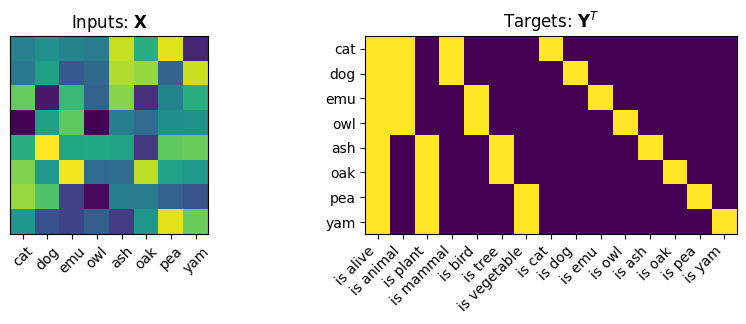

In [44]:
objects = ["cat", "dog", "emu", "owl", "ash", "oak", "pea", "yam"]
categories = ["alive", "animal", "plant", "mammal", "bird", "tree", "vegetable"] + objects

xs = jax.random.orthogonal(jax.random.key(1), len(objects)) # np.eye(len(objects))
ys = np.asarray([
    [1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], # cat
    [1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], # dog
    [1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # emu
    [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], # owl
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], # ash
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], # oak
    [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], # pea
    [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1], # TODO: Insert the target vector for yam
]).T

fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].imshow(xs)
axs[0].set_xticks(range(len(objects)))
axs[0].set_xticklabels(objects, rotation=45)
axs[0].set_yticks([])
axs[0].set_title("Inputs: $\\mathbf{X}$")

axs[1].imshow(ys.T)
axs[1].set_xticks(range(len(categories)))
axs[1].set_xticklabels([f"is {c}" for c in categories], rotation=45, ha="right")
axs[1].set_yticks(range(len(objects)))
axs[1].set_yticklabels(objects)
axs[1].set_title("Targets: $\\mathbf{Y}^T$")

fig.tight_layout()

Now that we have defined a task and network with its parameters - usually the next step is to train the network using your favorite learning algrithm - but this is where the magic of linear networks comes in - we don't have to do that!

### Solving the task with linear regression

Laurent and Brecht (2018) showed that under a mild set of assumptions, all minima of deep linear networks are equivalent to the corresponding single-layer linear regression problem. So in the case of the mean-squared error
$$\mathcal{L} = \frac{1}{2P} \sum_{n=1}^P||\mathbf{W}_2\mathbf{W}_1\mathbf{x}_n - \mathbf{y}_n||_2^2$$
the **optimal** and **only** optimal thing that our two-layer linear network can do is to perform linear regression - let's do it!

The global optima of the network thus corresponds to
$$\begin{aligned}
\frac{\mathcal{L}}{\mathbf{W}_2\mathbf{W}_1} &= 0\\
\Leftrightarrow \frac{1}{2P} \sum_{n=1}^P \left(\mathbf{W}_2\mathbf{W}_1 \mathbf{x}_n - \mathbf{y}_n \right) \mathbf{x}^T &= 0\\
\Leftrightarrow \mathbf{W}_2\mathbf{W}_1 \frac{1}{2P} \sum_{n=1}^P \mathbf{x}_n \mathbf{x}_n^T &= \sum_{n=1}^P \mathbf{y}_n \mathbf{x}_n^T\\
\Leftrightarrow \mathbf{W}_2\mathbf{W}_1 \mathbf{\Sigma}_{xx} &= \mathbf{\Sigma}_{yx},
\end{aligned}$$
where $\mathbf{\Sigma}_{xx}$ and $\mathbf{\Sigma}_{yx}$ denote the input and input-output covariance matrices. Then (under the assumption that $\mathbf{X}$ is of full rank) solving for the network function then yields
$$\begin{aligned}
\mathbf{W}_2\mathbf{W}_1 \mathbf{\Sigma}_{xx} &= \mathbf{\Sigma}_{yx}\\
\Leftrightarrow \mathbf{W}_2\mathbf{W}_1 &= \mathbf{\Sigma}_{yx} \mathbf{\Sigma}_{xx}^{-1},
\end{aligned}$$
which is simply linear regression.


The mean squared error of the network function is 0.0



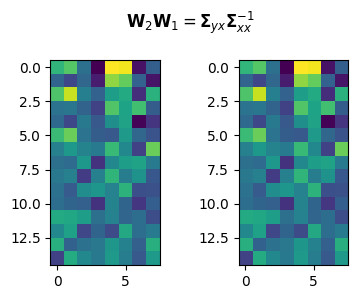

In [68]:
def mse(y_hat, ys):
    p = ys.shape[1]
    return np.sum((y_hat - ys)**2) / (2.0 * p)

w2w1 = ys @ xs.T @ np.linalg.pinv(xs @ xs.T)

fig, axs = plt.subplots(1, 2, figsize=(4, 3))
axs[0].imshow(w2w1)
axs[1].imshow(ys @ xs.T @ np.linalg.pinv(xs @ xs.T))
fig.suptitle("$\\mathbf{W}_2\\mathbf{W}_1 = \\mathbf{\\Sigma}_{yx}\\mathbf{\\Sigma}_{xx}^{-1}$")
fig.tight_layout()

print(f"\nThe mean squared error of the network function is {mse(w2w1 @ xs, ys):.1f}\n")

Crucially, any combination of $\mathbf{W}_2$ and $\mathbf{W}_1$ for which $\mathbf{W}_2\mathbf{W}_1 = \mathbf{\Sigma}_{yx} \mathbf{\Sigma}_{xx}^{-1}$ implements a valid and optimal solution! Therefore, there exist many solutions. Formally, the set of all such combinations defines the solution manifold
$$\mathcal{M} = \left\{\mathbf{W}_2\mathbf{W}_1 : \mathbf{W}_2\mathbf{W}_1\mathbf{\Sigma}_{xx} = \mathbf{\Sigma}_{xx}\right\}$$
(read: the set $\mathcal{M}$ is equal to the collection of all combinations of $\mathbf{W}_2\mathbf{W}_1$ for which ":" the equality holds). So this is rather abstract and not really intuitive or outright clear. Also, what has this anything to do with representatinal comparisons?! So let's make it even more simple - let's understand the solution manifold of the simplest two-layer network with one input, one hidden neuron, and one output - and the connection will become clear in no time!

### Solution manifolds of two-layer linear networks

Let's study the scalar two layer linear network for which $\hat{y} = w_2w_1 x$, where $\hat{y}$, $w_2$, $w_1$ and $x$ are all scalars. Let's make the situation even more simple and let's assume that $x=1$ and $y=2$. Then, for $w_1=2$, $w_2=1$ it follows that $w_2w_1x = 2$, and therefore $w_2w_1x$ is a solution. However, $w_1=\sqrt{2}$, $w_2=\sqrt{2}$ is a solution too! More formally, we can say that 


If we now collect all these solution for any $q \neq 0$ - this is the solution manifold - and any specific solution is a point on this solution manifold. We can neatly visualize this in weight space

In [ ]:
we note for the affectionatos that one has in general to be more careful because of the input null space

In [ ]:
def network(w1, w2, x):
    return w2 @ w1 @ x



## Function and representations are fundamentally dissociable

## Going beyond linear-regression with the teacher-student paradigm

One of the main advantages of the two-layer linear network setting is that we exactly know what is optimal, a privileague that we generally do not have in task-driven non-linear neural networks - because we do not know how to do the math to determine optimality. Fortunately, there does exist a setting in which optimallity is well-defined - the so called teacher-student paradigm. Instead of defining a task via a set of inputs and outputs, we are going to define a _teacher_ neural network as target computation and try to learn this computation in a _student_ neural network.

Under a mild set of assumptions, one can show 

### A list of questions that people usually have after being confronted with out work and that we maybe should / could address
- But what if we make the network deeper?
- But what if we make the network wider?
- But how about different network architectures (conv nets / transformers)?
- But what if we change the loss function?
- But how about only positivie firing rates / weights etc.